# Import Packages

In [143]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

# Load Data

In [144]:
data = pd.read_csv("./norauto.csv")

In [145]:
data.head()

,Male,Young,DistLimit,GeoRegion,Expo,ClaimAmount,NbClaim
0,0,0,12000 km,Low+,0.789,0.0,0
1,0,1,12000 km,Medium+,0.200,0.0,0
2,0,1,25000-30000 km,Medium+,0.285,0.0,0
3,0,0,12000 km,Medium-,0.247,0.0,0
4,0,0,12000 km,High-,0.995,18158.0,1


## Explanatory Analysis and Data Processing

In [146]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183999 entries, 0 to 183998
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Male         183999 non-null  int64  
 1   Young        183999 non-null  int64  
 2   DistLimit    183999 non-null  object 
 3   GeoRegion    183999 non-null  object 
 4   Expo         183999 non-null  float64
 5   ClaimAmount  183999 non-null  float64
 6   NbClaim      183999 non-null  int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 9.8+ MB


### Numerical Data

In [147]:
data.describe()

,Male,Young,Expo,ClaimAmount,NbClaim
count,183999.000000,183999.000000,183999.000000,183999.000000,183999.000000
mean,0.976016,0.243143,0.662211,1082.508503,0.047674
std,0.152999,0.428982,0.511311,7905.678281,0.221653
min,0.000000,0.000000,0.101000,0.000000,0.000000
25%,1.000000,0.000000,0.310000,0.000000,0.000000
50%,1.000000,0.000000,0.575000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,0.000000,0.000000
max,1.000000,1.000000,25.849000,700000.000000,3.000000


### Categorical Data

In [148]:
cat_col = data.select_dtypes("object").columns

for col in cat_col:
    print("\n", data[col].value_counts())


 DistLimit
no limit          53689
20000 km          37007
12000 km          34307
25000-30000 km    30763
8000 km           15264
16000 km          12969
Name: count, dtype: int64

 GeoRegion
High-      55308
High+      44212
Medium+    41493
Medium-    25925
Low+       14135
Low-        2926
Name: count, dtype: int64


## Data Feature Engineering: Relevelling and New Feature Creation

In [149]:
data["DistLimit"] = pd.Categorical(data["DistLimit"], categories=["8000 km", "12000 km", "16000 km", "20000 km", "25000-30000 km", "no limit"], ordered=True)
data["GeoRegion"] = pd.Categorical(data["GeoRegion"], categories = ["High+", "High-", "Medium+", "Medium-", "Low+", "Low-"], ordered = True)

data["LogExpo"] = np.log(data["Expo"])

### Male: Total Exposure and Total No. of Claims

In [150]:
data.groupby("Male")[["Expo", "NbClaim"]].sum()

,Expo,NbClaim
Male,,
0,2376.642,296
1,119469.429,8476


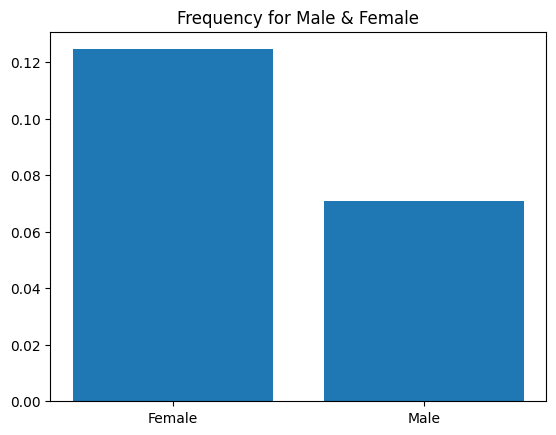

In [182]:
male_freq = data.groupby("Male")[["Expo", "NbClaim"]].sum().reset_index()
plt.bar(x = male_freq["Male"], height = male_freq["NbClaim"] / male_freq["Expo"])
plt.xticks(ticks = [0, 1], labels = ["Female", "Male"])
plt.title("Frequency for Male & Female")
plt.show()

### Young: Total Exposure and Total No. of Claims

In [152]:
data.groupby("Young")[["Expo", "NbClaim"]].sum()

,Expo,NbClaim
Young,,
0,92213.975,6497
1,29632.096,2275


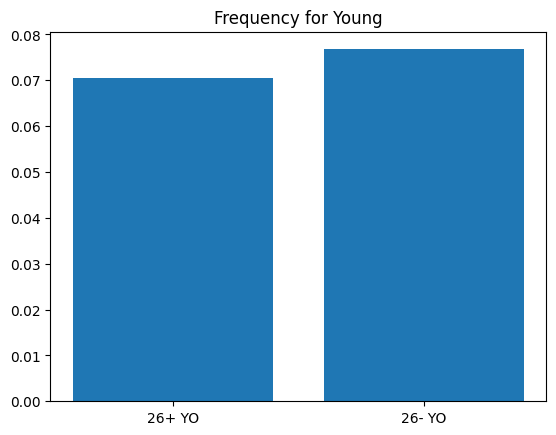

In [183]:
young_freq = data.groupby("Young")[["Expo", "NbClaim"]].sum().reset_index()

plt.bar(x = young_freq["Young"], height = young_freq["NbClaim"] / young_freq["Expo"])
plt.xticks(ticks = [0, 1], labels = ["26+ YO", "26- YO"])
plt.xlabel("")
plt.title("Frequency for Young")
plt.show()

### DistLimit: Total Exposure and Total No. of Claims

In [154]:
data.groupby("DistLimit", observed=True)[["Expo", "NbClaim"]].sum().reset_index()

,DistLimit,Expo,NbClaim
0,8000 km,12081.811,552
1,12000 km,23370.523,1213
2,16000 km,9373.382,540
3,20000 km,23359.560,1655
4,25000-30000 km,19087.215,1511
5,no limit,34573.580,3301


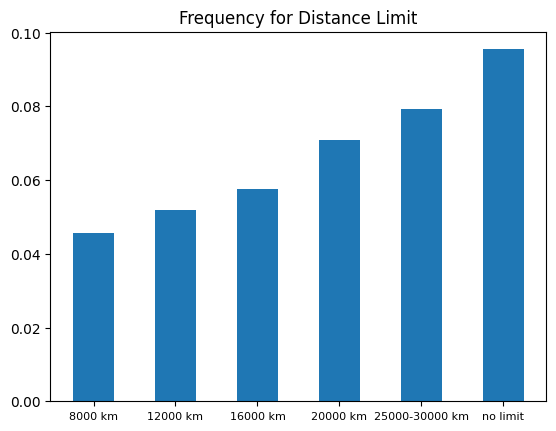

In [184]:
DistLimit_freq = data.groupby("DistLimit", observed=True)[["Expo", "NbClaim"]].sum().reset_index()
plt.bar(x = DistLimit_freq["DistLimit"], height = DistLimit_freq["NbClaim"] / DistLimit_freq["Expo"], width = 0.5)
plt.xticks(fontsize = 8)
plt.xlabel("")
plt.title("Frequency for Distance Limit")
plt.show()

### GeoRegion: Total Exposure and Total No. of Claims

In [156]:
data.groupby("GeoRegion", observed=True)[["Expo", "NbClaim"]].sum().reset_index()

,GeoRegion,Expo,NbClaim
0,High+,31386.751,2632
1,High-,37412.742,2642
2,Medium+,26965.651,1843
3,Medium-,16038.192,1057
4,Low+,8366.369,507
5,Low-,1676.366,91


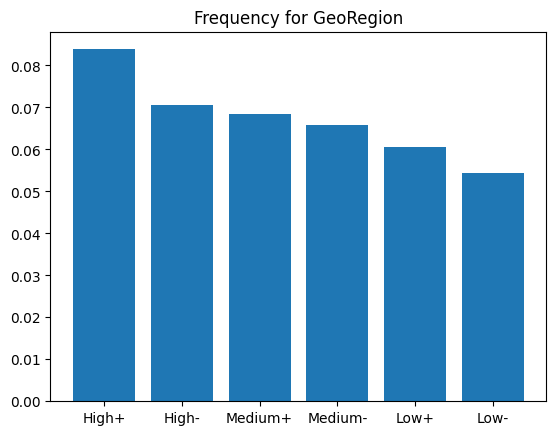

In [185]:
GeoRegion_freq = data.groupby("GeoRegion", observed=True)[["Expo", "NbClaim"]].sum().reset_index()
plt.bar(x = GeoRegion_freq["GeoRegion"], height = GeoRegion_freq["NbClaim"] / GeoRegion_freq["Expo"])
plt.xlabel("")
plt.title("Frequency for GeoRegion")
plt.show()

# Train & Test Data-Split

In [158]:
train, test = train_test_split(data, test_size=0.2, random_state=999)

In [159]:
print("Train Data: {} Rows * {} Columns".format(train.shape[0], train.shape[1]))
print("Test Data: {} Rows * {} Columns".format(test.shape[0], test.shape[1]))

Train Data: 147199 Rows * 8 Columns
Test Data: 36800 Rows * 8 Columns


# Frequency Modelling

In [160]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

## Poisson 

In [161]:
poisson_glm_full = smf.glm("NbClaim ~ Male + Young + GeoRegion + DistLimit", exposure = train["Expo"], data=train, family=sm.families.Poisson(link=sm.families.links.Log()))
poisson_full_results = poisson_glm_full.fit()
print(poisson_full_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                NbClaim   No. Observations:               147199
Model:                            GLM   Df Residuals:                   147186
Model Family:                 Poisson   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -26601.
Date:                Thu, 09 Jul 2026   Deviance:                       39590.
Time:                        21:45:11   Pearson chi2:                 1.45e+05
No. Iterations:                     7   Pseudo R-squ. (CS):           0.004373
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [162]:
poisson_full_results.aic

np.float64(53228.67450827209)

## Negative Binomial

In [163]:
nb = smf.negativebinomial("NbClaim ~ Male + Young + GeoRegion + DistLimit ", data=train, offset=np.log(train["Expo"])).fit(maxiter=500)

Optimization terminated successfully.
         Current function value: 0.180717
         Iterations: 71
         Function evaluations: 75
         Gradient evaluations: 75


In [164]:
alpha = np.exp(nb.lnalpha)

In [165]:
NB_glm_full = smf.glm("NbClaim ~ Male + Young + GeoRegion + DistLimit", exposure = train["Expo"], data=train, family=sm.families.NegativeBinomial(link=sm.families.links.Log(), alpha = alpha))
NB_full_results = NB_glm_full.fit()
print(NB_full_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                NbClaim   No. Observations:               147199
Model:                            GLM   Df Residuals:                   147186
Model Family:        NegativeBinomial   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -26601.
Date:                Thu, 09 Jul 2026   Deviance:                       39581.
Time:                        21:45:35   Pearson chi2:                 1.45e+05
No. Iterations:                     7   Pseudo R-squ. (CS):           0.004373
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [166]:
NB_full_results.aic

np.float64(53228.68739387782)

## Model Performance

In [167]:
performance_dict = {
                    "Model": ["Poisson", "Negative Binomial"],
                    "AIC": [poisson_full_results.aic, NB_full_results.aic],
                    "Dispersion": [poisson_full_results.pearson_chi2/poisson_full_results.df_resid, NB_full_results.pearson_chi2/NB_full_results.df_resid]
                   }

performance = pd.DataFrame(performance_dict)

In [168]:
print(performance)

# Poisson Model is selected

               Model           AIC  Dispersion
0            Poisson  53228.674508    0.987004
1  Negative Binomial  53228.687394    0.986942


# Severity Modelling

In [169]:
sev_train = train[train["ClaimAmount"] > 0].copy()
sev_test = test[test["ClaimAmount"] > 0].copy()

### Gamma without Interaction Term

In [170]:
sev_gamma_full = smf.glm("ClaimAmount ~ Male + Young + GeoRegion + DistLimit", data=sev_train, family=sm.families.Gamma(link=sm.families.links.Log()))
sev_gamma_results = sev_gamma_full.fit()
sev_gamma_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:            ClaimAmount   No. Observations:                 6728
Model:                            GLM   Df Residuals:                     6715
Model Family:                   Gamma   Df Model:                           12
Link Function:                    Log   Scale:                          1.4461
Method:                          IRLS   Log-Likelihood:                -74910.
Date:                Thu, 09 Jul 2026   Deviance:                       6741.1
Time:                        21:45:57   Pearson chi2:                 9.71e+03
No. Iterations:                    11   Pseudo R-squ. (CS):           0.001126
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      10.0687      0.103     98.220      0.000       9.868      10.270
GeoRegion[T.High-]              0.0125      0.038      0.329      0.742      -0.062       0.087
GeoRegion[T.Medium+]            0.0188      0.042      0.444      0.657      -0.064       0.102
GeoRegion[T.Medium-]            0.0029      0.050      0.059      0.953      -0.095       0.101
GeoRegion[T.Low+]               0.0083      0.066      0.125      0.901      -0.122       0.138
GeoRegion[T.Low-]              -0.2185      0.151     -1.449      0.147      -0.514       0.077
DistLimit[T.12000 km]           0.0644      0.071      0.910      0.363      -0.074       0.203
DistLimit[T.16000 km]           0.0977      0.084      1.168      0.243      -0.066       0.262
DistLimit[T.20000 km]           0.0770      0.068      1.137      0.256      -0.056       0.210
DistLimit[T.25000-30000 km]     0.0490      0.069      0.713      0.476      -0.086       0.183
DistLimit[T.no limit]           0.0077      0.064      0.121      0.904      -0.117       0.133
Male                           -0.0441      0.081     -0.547      0.584      -0.202       0.114
Young                          -0.0107      0.034     -0.318      0.750      -0.077       0.055
===============================================================================================
"""

### Gamma with Interaction Term

In [171]:
sev_gamma_full_inter = smf.glm("ClaimAmount ~ Male * Young + GeoRegion + DistLimit", data=sev_train, family=sm.families.Gamma(link=sm.families.links.Log()))
sev_gamma_inter_results = sev_gamma_full_inter.fit()
sev_gamma_inter_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:            ClaimAmount   No. Observations:                 6728
Model:                            GLM   Df Residuals:                     6714
Model Family:                   Gamma   Df Model:                           13
Link Function:                    Log   Scale:                          1.4398
Method:                          IRLS   Log-Likelihood:                -74900.
Date:                Thu, 09 Jul 2026   Deviance:                       6736.0
Time:                        21:45:59   Pearson chi2:                 9.67e+03
No. Iterations:                    11   Pseudo R-squ. (CS):           0.001654
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      10.1440      0.111     91.098      0.000       9.926      10.362
GeoRegion[T.High-]              0.0146      0.038      0.385      0.700      -0.060       0.089
GeoRegion[T.Medium+]            0.0192      0.042      0.453      0.651      -0.064       0.102
GeoRegion[T.Medium-]            0.0046      0.050      0.092      0.927      -0.093       0.102
GeoRegion[T.Low+]               0.0060      0.066      0.091      0.927      -0.124       0.136
GeoRegion[T.Low-]              -0.2213      0.150     -1.471      0.141      -0.516       0.074
DistLimit[T.12000 km]           0.0661      0.071      0.936      0.349      -0.072       0.205
DistLimit[T.16000 km]           0.0972      0.084      1.163      0.245      -0.067       0.261
DistLimit[T.20000 km]           0.0788      0.068      1.165      0.244      -0.054       0.211
DistLimit[T.25000-30000 km]     0.0511      0.069      0.746      0.456      -0.083       0.185
DistLimit[T.no limit]           0.0088      0.064      0.139      0.890      -0.116       0.133
Male                           -0.1245      0.093     -1.335      0.182      -0.307       0.058
Young                          -0.3557      0.181     -1.962      0.050      -0.711      -0.000
Male:Young                      0.3561      0.184      1.931      0.054      -0.005       0.718
===============================================================================================
"""

## LogNormal

In [172]:
sev_train["Log_ClaimAmount"] = np.log(sev_train["ClaimAmount"])

In [173]:
sev_LogNormal_full_inter = smf.glm("Log_ClaimAmount ~ Male * Young + GeoRegion + DistLimit", data=sev_train, family=sm.families.Gaussian(link=sm.families.links.Identity()))
sev_LogNormal_full_inter_results = sev_LogNormal_full_inter.fit()
print(sev_LogNormal_full_inter_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:        Log_ClaimAmount   No. Observations:                 6728
Model:                            GLM   Df Residuals:                     6714
Model Family:                Gaussian   Df Model:                           13
Link Function:               Identity   Scale:                          1.4518
Method:                          IRLS   Log-Likelihood:                -10794.
Date:                Thu, 09 Jul 2026   Deviance:                       9747.2
Time:                        21:46:05   Pearson chi2:                 9.75e+03
No. Iterations:                     3   Pseudo R-squ. (CS):           0.001970
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

## Model Performance

In [174]:
from sklearn.metrics import mean_squared_error

In [175]:
sev_porformance_dict = {
                        "Model": ["Gamma without Interaction", "Gamma with Interaction", "LogNormal with Interaction"],
                        "MSE": [mean_squared_error(sev_gamma_results.predict(sev_test), sev_test["ClaimAmount"]),
                                mean_squared_error(sev_gamma_inter_results.predict(sev_test), sev_test["ClaimAmount"]),
                                mean_squared_error(np.exp(sev_LogNormal_full_inter_results.predict(sev_test)), sev_test["ClaimAmount"])]
                       }

In [177]:
sev_performance_summary = pd.DataFrame(sev_porformance_dict)
sev_performance_summary.sort_values("MSE")

,Model,MSE
1,Gamma with Interaction,8.955628e+08
0,Gamma without Interaction,8.958385e+08
2,LogNormal with Interaction,9.759946e+08


In [178]:
#sev_gamma_pred = sev_gamma_results.predict(test)
sev_gamma_pred = sev_gamma_inter_results.predict(test)
freq_poisson_pred = poisson_full_results.predict(test, exposure=test["Expo"])
pure_premium = sev_gamma_pred * freq_poisson_pred

In [179]:
summary = pd.DataFrame({"Policies": [test.shape[0]], 
                        "MeanSev": [sev_LogNormal_pred.mean()], 
                        "MeanFreq": [freq_poisson_pred.mean()], 
                        "MeanPurePrem": [pure_premium.mean()], 
                        "Observed.TotalLoss": [test["ClaimAmount"].sum()]})

summary["pred.PurePremium"] = summary["MeanPurePrem"] * summary["Policies"]
summary["Pred / Observed"] = summary["pred.PurePremium"] / summary["Observed.TotalLoss"]

In [180]:
summary

,Policies,MeanSev,MeanFreq,MeanPurePrem,Observed.TotalLoss,pred.PurePremium,Pred / Observed
0,36800,14347.960527,0.047607,1125.89031,40008706.0,4.143276e+07,1.035594


# Gross Premium: Premium Method

In [ ]:
# p120,126

#permissible loss ratio = 1 - Variable Expense Ratio - Profit Margin
#set ratio = 0.7

In [186]:
permissible_loss_ratio = 0.7
summary["MeanPurePrem"] / permissible_loss_ratio

0    1608.414729
Name: MeanPurePrem, dtype: float64

In [187]:
summary["GrossPremium"] = summary["MeanPurePrem"] / permissible_loss_ratio
summary

,Policies,MeanSev,MeanFreq,MeanPurePrem,Observed.TotalLoss,pred.PurePremium,Pred / Observed,GrossPremium
0,36800,14347.960527,0.047607,1125.89031,40008706.0,4.143276e+07,1.035594,1608.414729
